In [ ]:
# ==========================================================
# Experiment 2
# Import Required Libraries
# ==========================================================

# Numerical Computing
import numpy as np

# Data Manipulation
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    AveragePooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.utils import to_categorical

# Evaluation Metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Display TensorFlow Version
print("=" * 60)
print("TensorFlow Version :", tf.__version__)
print("NumPy Version      :", np.__version__)
print("Pandas Version     :", pd.__version__)
print("=" * 60)

TensorFlow Version : 2.20.0
NumPy Version      : 2.0.2
Pandas Version     : 2.2.2


In [ ]:
# ==========================================================
# Load CIFAR-10 Dataset
# ==========================================================

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("=" * 60)
print("Dataset Loaded Successfully")
print("=" * 60)

print(f"Training Images Shape : {X_train.shape}")
print(f"Training Labels Shape : {y_train.shape}")

print()

print(f"Testing Images Shape  : {X_test.shape}")
print(f"Testing Labels Shape  : {y_test.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2811s 16us/step
Dataset Loaded Successfully
Training Images Shape : (50000, 32, 32, 3)
Training Labels Shape : (50000, 1)

Testing Images Shape  : (10000, 32, 32, 3)
Testing Labels Shape  : (10000, 1)


In [ ]:
# ==========================================================
# Define Class Labels
# ==========================================================

class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

print("Classes in CIFAR-10 Dataset:\n")

for i, label in enumerate(class_names):
    print(f"{i} --> {label}")

Classes in CIFAR-10 Dataset:

0 --> Airplane
1 --> Automobile
2 --> Bird
3 --> Cat
4 --> Deer
5 --> Dog
6 --> Frog
7 --> Horse
8 --> Ship
9 --> Truck


In [ ]:
# ==========================================================
# Dataset Summary
# ==========================================================

summary = pd.DataFrame({
    "Property": [
        "Dataset Name",
        "Training Images",
        "Testing Images",
        "Total Images",
        "Image Height",
        "Image Width",
        "Color Channels",
        "Number of Classes"
    ],
    "Value": [
        "CIFAR-10",
        len(X_train),
        len(X_test),
        len(X_train) + len(X_test),
        X_train.shape[1],
        X_train.shape[2],
        X_train.shape[3],
        len(class_names)
    ]
})

summary

,Property,Value
0,Dataset Name,CIFAR-10
1,Training Images,50000
2,Testing Images,10000
3,Total Images,60000
4,Image Height,32
5,Image Width,32
6,Color Channels,3
7,Number of Classes,10


In [ ]:
# ==========================================================
# Dataset Information
# ==========================================================

print("=" * 60)
print("Training Dataset Information")
print("=" * 60)

print("Image Data Type :", X_train.dtype)
print("Pixel Range     :", X_train.min(), "to", X_train.max())
print("Label Data Type :", y_train.dtype)

print()

print("=" * 60)
print("Testing Dataset Information")
print("=" * 60)

print("Image Data Type :", X_test.dtype)
print("Pixel Range     :", X_test.min(), "to", X_test.max())
print("Label Data Type :", y_test.dtype)

Training Dataset Information
Image Data Type : uint8
Pixel Range     : 0 to 255
Label Data Type : uint8

Testing Dataset Information
Image Data Type : uint8
Pixel Range     : 0 to 255
Label Data Type : uint8


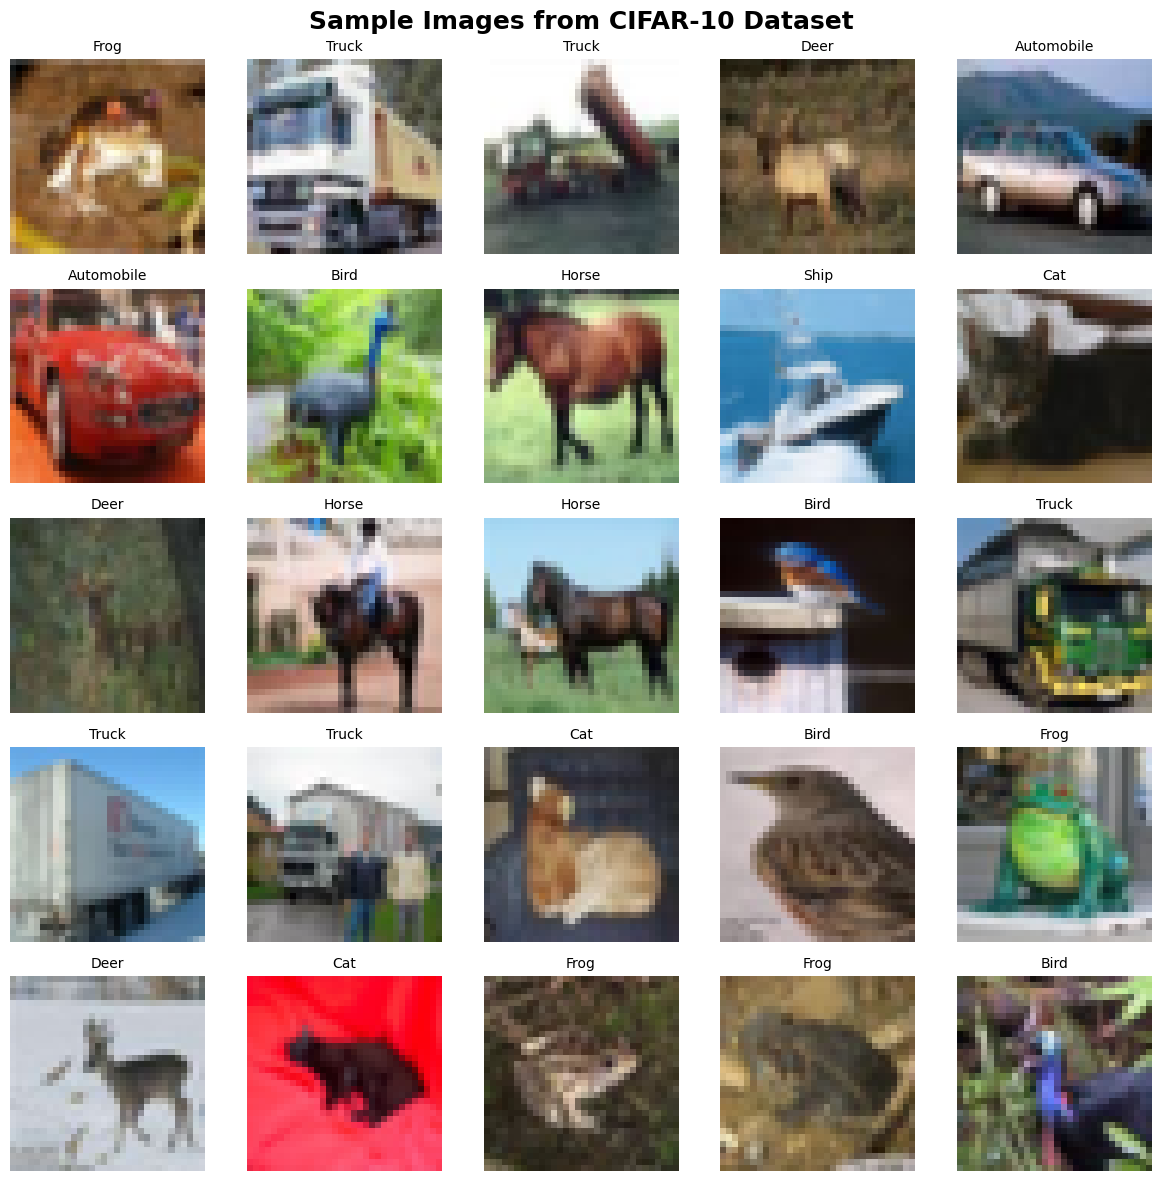

In [ ]:
# ==========================================================
# Display Random Sample Images
# ==========================================================

plt.figure(figsize=(12, 12))

for i in range(25):

    plt.subplot(5, 5, i + 1)

    plt.imshow(X_train[i])

    plt.title(class_names[y_train[i][0]], fontsize=10)

    plt.axis("off")

plt.suptitle("Sample Images from CIFAR-10 Dataset", fontsize=18, fontweight="bold")

plt.tight_layout()

plt.show()

,Class,Number of Images
0,Airplane,5000
1,Automobile,5000
2,Bird,5000
3,Cat,5000
4,Deer,5000
5,Dog,5000
6,Frog,5000
7,Horse,5000
8,Ship,5000
9,Truck,5000


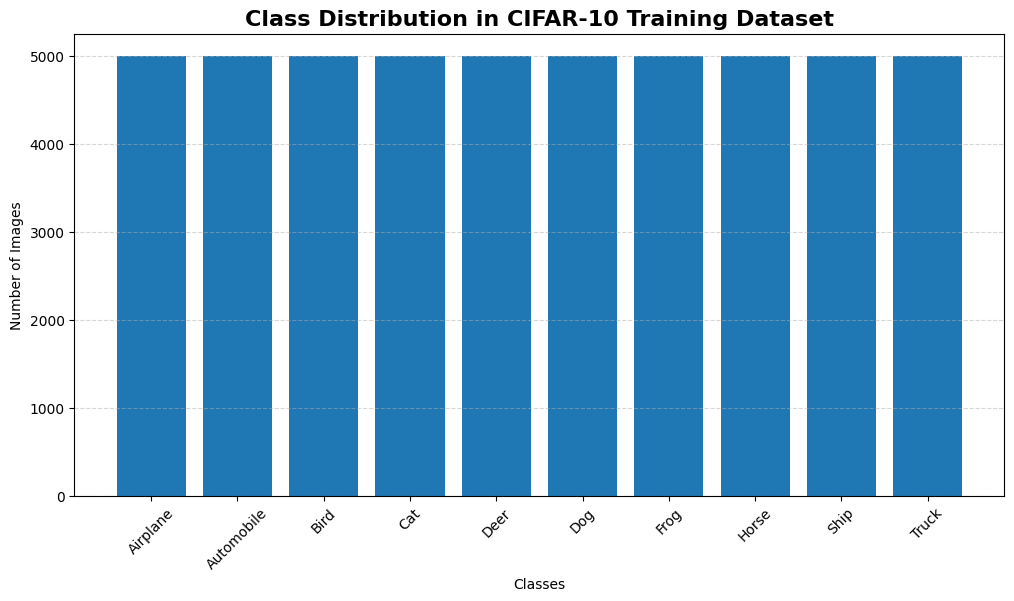

In [ ]:
# ==========================================================
# Visualize Class Distribution
# ==========================================================

unique_classes, class_counts = np.unique(y_train, return_counts=True)

distribution = pd.DataFrame({
    "Class": [class_names[i] for i in unique_classes],
    "Number of Images": class_counts
})

display(distribution)

plt.figure(figsize=(12, 6))

plt.bar(distribution["Class"], distribution["Number of Images"])

plt.title("Class Distribution in CIFAR-10 Training Dataset",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Classes")

plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [ ]:
# ==========================================================
# Normalize Image Pixel Values
# ==========================================================

# Convert uint8 to float32
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

print("=" * 60)
print("Image Normalization Completed Successfully")
print("=" * 60)

print("Training Image Range :", X_train.min(), "to", X_train.max())
print("Testing Image Range  :", X_test.min(), "to", X_test.max())

Image Normalization Completed Successfully
Training Image Range : 0.0 to 1.0
Testing Image Range  : 0.0 to 1.0


In [ ]:
# ==========================================================
# One-Hot Encode Labels
# ==========================================================

y_train_encoded = to_categorical(y_train, 10)
y_test_encoded = to_categorical(y_test, 10)

print("=" * 60)
print("One-Hot Encoding Completed")
print("=" * 60)

print("Training Labels Shape :", y_train_encoded.shape)
print("Testing Labels Shape  :", y_test_encoded.shape)

# ==========================================================
# Display Sample Labels
# ==========================================================

print("Original Label        :", y_train[0][0])
print()

print("One-Hot Encoded Label :")

print(y_train_encoded[0])

One-Hot Encoding Completed
Training Labels Shape : (50000, 10)
Testing Labels Shape  : (10000, 10)
Original Label        : 6

One-Hot Encoded Label :
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


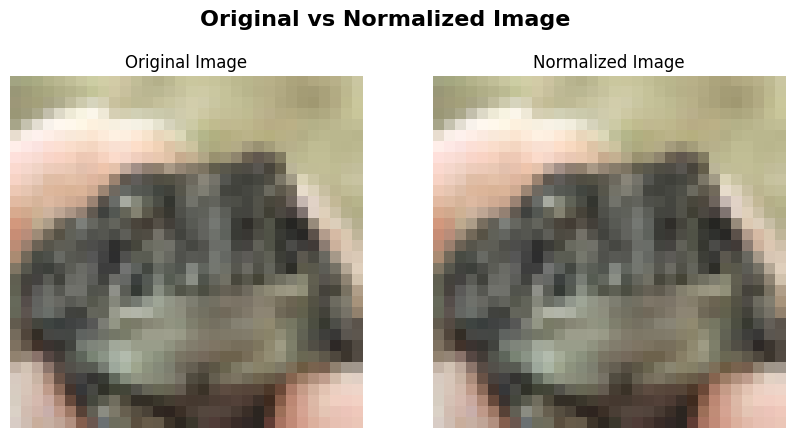

In [ ]:
# ==========================================================
# Compare Original and Normalized Images
# ==========================================================

sample_index = 25

# Original Image (Convert back to uint8 for display)
original_image = (X_train[sample_index] * 255).astype("uint8")

normalized_image = X_train[sample_index]

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(original_image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(normalized_image)
plt.title("Normalized Image")
plt.axis("off")

plt.suptitle("Original vs Normalized Image",
             fontsize=16,
             fontweight="bold")

plt.show()

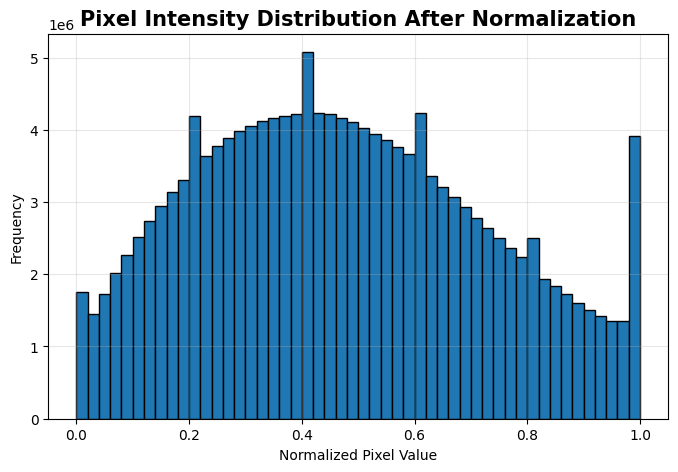

In [ ]:
# ==========================================================
# Pixel Intensity Distribution
# ==========================================================

plt.figure(figsize=(8,5))

plt.hist(X_train.flatten(),
         bins=50,
         edgecolor='black')

plt.title("Pixel Intensity Distribution After Normalization",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Normalized Pixel Value")

plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

In [ ]:
# ==========================================================
# Final Dataset Summary After Preprocessing
# ==========================================================

print("=" * 60)
print("Final Dataset Summary")
print("=" * 60)

print("Training Images :", X_train.shape)
print("Testing Images  :", X_test.shape)

print()

print("Training Labels :", y_train_encoded.shape)
print("Testing Labels  :", y_test_encoded.shape)

print()

print("Training Image Range :", X_train.min(), "-", X_train.max())
print("Testing Image Range  :", X_test.min(), "-", X_test.max())

print()

print("Data Type :", X_train.dtype)

Final Dataset Summary
Training Images : (50000, 32, 32, 3)
Testing Images  : (10000, 32, 32, 3)

Training Labels : (50000, 10)
Testing Labels  : (10000, 10)

Training Image Range : 0.0 - 1.0
Testing Image Range  : 0.0 - 1.0

Data Type : float32


In [ ]:
# ==========================================================
# Build the CNN Model
# ==========================================================

model = Sequential([

    # -------------------------
    # First Convolution Block
    # -------------------------
    Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation='relu',
        padding='same',
        input_shape=(32, 32, 3)
    ),

    BatchNormalization(),

    MaxPooling2D(pool_size=(2, 2)),


    # -------------------------
    # Second Convolution Block
    # -------------------------
    Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation='relu',
        padding='same'
    ),

    BatchNormalization(),

    MaxPooling2D(pool_size=(2, 2)),


    # -------------------------
    # Third Convolution Block
    # -------------------------
    Conv2D(
        filters=128,
        kernel_size=(3, 3),
        activation='relu',
        padding='same'
    ),

    BatchNormalization(),

    MaxPooling2D(pool_size=(2, 2)),


    # -------------------------
    # Classification Head
    # -------------------------
    Flatten(),

    Dense(
        units=128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        units=10,
        activation='softmax'
    )

])

print("="*60)
print("CNN Model Successfully Created")
print("="*60)

# ==========================================================
# Display Model Summary
# ==========================================================

print("="*60)
print("CNN Model Summary")
print("="*60)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN Model Successfully Created
CNN Model Summary


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,706 (1.36 MB)

 Trainable params: 357,258 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# ==========================================================
# Compile CNN Model
# ==========================================================

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("="*60)
print("CNN Model Compiled Successfully")
print("="*60)

print("Optimizer :", "Adam")
print("Loss      :", "Categorical Crossentropy")
print("Metric    :", "Accuracy")

# ==========================================================
# Display Layer Information
# ==========================================================

for i, layer in enumerate(model.layers):

    print(f"Layer {i+1}")

    print("Name :", layer.name)

    print("Type :", layer.__class__.__name__)

    print("-"*40)

CNN Model Compiled Successfully
Optimizer : Adam
Loss      : Categorical Crossentropy
Metric    : Accuracy
Layer 1
Name : conv2d
Type : Conv2D
----------------------------------------
Layer 2
Name : batch_normalization
Type : BatchNormalization
----------------------------------------
Layer 3
Name : max_pooling2d
Type : MaxPooling2D
----------------------------------------
Layer 4
Name : conv2d_1
Type : Conv2D
----------------------------------------
Layer 5
Name : batch_normalization_1
Type : BatchNormalization
----------------------------------------
Layer 6
Name : max_pooling2d_1
Type : MaxPooling2D
----------------------------------------
Layer 7
Name : conv2d_2
Type : Conv2D
----------------------------------------
Layer 8
Name : batch_normalization_2
Type : BatchNormalization
----------------------------------------
Layer 9
Name : max_pooling2d_2
Type : MaxPooling2D
----------------------------------------
Layer 10
Name : flatten
Type : Flatten
-----------------------------------

In [ ]:
# ==========================================================
# Train the CNN Model
# ==========================================================

import time

print("=" * 60)
print("Training Started...")
print("=" * 60)

start_time = time.time()

history = model.fit(
    X_train,
    y_train_encoded,
    epochs=20,
    batch_size=64,
    validation_split=0.20,
    verbose=1
)

end_time = time.time()

training_time = end_time - start_time

print("\n" + "=" * 60)
print("Training Completed Successfully!")
print("=" * 60)

print(f"Total Training Time : {training_time:.2f} seconds")

Training Started...
Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 133s 207ms/step - accuracy: 0.4013 - loss: 1.6769 - val_accuracy: 0.4899 - val_loss: 1.4646
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 139s 204ms/step - accuracy: 0.5405 - loss: 1.2909 - val_accuracy: 0.5739 - val_loss: 1.2461
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 146s 211ms/step - accuracy: 0.6090 - loss: 1.1136 - val_accuracy: 0.5422 - val_loss: 1.3707
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 130s 208ms/step - accuracy: 0.6542 - loss: 0.9883 - val_accuracy: 0.5712 - val_loss: 1.2736
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 146s 214ms/step - accuracy: 0.6883 - loss: 0.8961 - val_accuracy: 0.6829 - val_loss: 0.9042
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 135s 203ms/step - accuracy: 0.7151 - loss: 0.8227 - val_accuracy: 0.7317 - val_loss: 0.7803
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 129s 207ms/step - accuracy: 0.7394 - loss: 0.7510 - val_accuracy: 0.7111 - val_loss: 0.8592
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 130s 208ms/step 

In [ ]:
# ==========================================================
# Training Summary
# ==========================================================

train_acc = max(history.history['accuracy'])
val_acc = max(history.history['val_accuracy'])

train_loss = min(history.history['loss'])
val_loss = min(history.history['val_loss'])

print("=" * 60)
print("Training Summary")
print("=" * 60)

print(f"Best Training Accuracy   : {train_acc:.4f}")
print(f"Best Validation Accuracy : {val_acc:.4f}")

print()

print(f"Lowest Training Loss     : {train_loss:.4f}")
print(f"Lowest Validation Loss   : {val_loss:.4f}")

Training Summary
Best Training Accuracy   : 0.8933
Best Validation Accuracy : 0.7612

Lowest Training Loss     : 0.3029
Lowest Validation Loss   : 0.7803


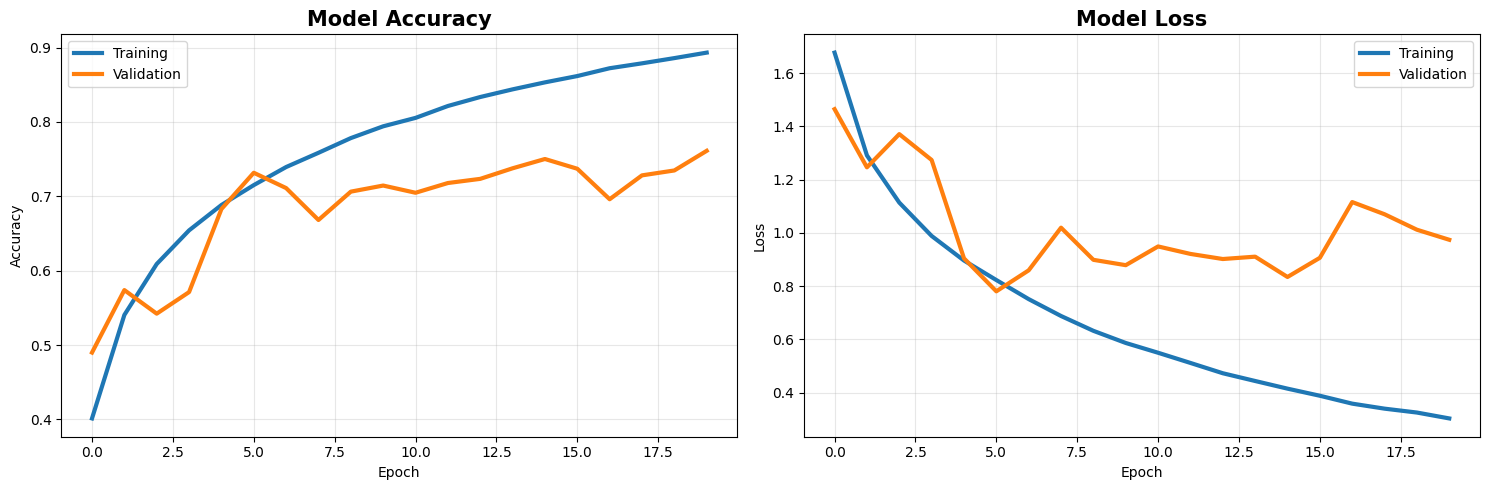

In [ ]:
# ==========================================================
# Combined Learning Curves
# ==========================================================

fig, axes = plt.subplots(1, 2, figsize=(15,5))

# Accuracy
axes[0].plot(history.history['accuracy'],
             linewidth=3,
             label='Training')

axes[0].plot(history.history['val_accuracy'],
             linewidth=3,
             label='Validation')

axes[0].set_title("Model Accuracy",
                  fontsize=15,
                  fontweight='bold')

axes[0].set_xlabel("Epoch")

axes[0].set_ylabel("Accuracy")

axes[0].legend()

axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],
             linewidth=3,
             label='Training')

axes[1].plot(history.history['val_loss'],
             linewidth=3,
             label='Validation')

axes[1].set_title("Model Loss",
                  fontsize=15,
                  fontweight='bold')

axes[1].set_xlabel("Epoch")

axes[1].set_ylabel("Loss")

axes[1].legend()

axes[1].grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
# ==========================================================
# Evaluate CNN on Test Dataset
# ==========================================================

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test_encoded,
    verbose=1
)

print("=" * 60)
print("Test Dataset Evaluation")
print("=" * 60)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

# ==========================================================
# Predict Classes
# ==========================================================

y_pred_prob = model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = y_test.flatten()

print("=" * 60)
print("Prediction Completed")
print("=" * 60)

313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - accuracy: 0.7575 - loss: 0.9858
Test Dataset Evaluation
Test Loss     : 0.9858
Test Accuracy : 0.7575
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step
Prediction Completed


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics
test_accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Create DataFrame
metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],

    "Score": [
        test_accuracy,
        precision,
        recall,
        f1
    ]
})

metrics_df

,Metric,Score
0,Accuracy,0.757500
1,Precision,0.757639
2,Recall,0.757500
3,F1-Score,0.756132


In [ ]:
# ==========================================================
# Classification Report
# ==========================================================

print("=" * 80)
print("Classification Report")
print("=" * 80)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

Classification Report
              precision    recall  f1-score   support

    Airplane       0.73      0.85      0.78      1000
  Automobile       0.90      0.85      0.87      1000
        Bird       0.67      0.66      0.67      1000
         Cat       0.61      0.52      0.56      1000
        Deer       0.71      0.73      0.72      1000
         Dog       0.68      0.65      0.66      1000
        Frog       0.76      0.85      0.80      1000
       Horse       0.76      0.82      0.79      1000
        Ship       0.88      0.82      0.85      1000
       Truck       0.87      0.84      0.85      1000

    accuracy                           0.76     10000
   macro avg       0.76      0.76      0.76     10000
weighted avg       0.76      0.76      0.76     10000



In [ ]:
# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[849   9  29  16  11   0   7  15  46  18]
 [ 20 846   2   6   7   5  10   6  20  78]
 [ 65   2 662  36  85  40  63  35   7   5]
 [ 36   2  74 519  66 166  83  46   4   4]
 [ 19   2  52  39 727  32  49  74   6   0]
 [ 15   3  53 141  56 648  29  49   5   1]
 [  8   2  46  42  28  17 849   4   2   2]
 [ 19   2  41  30  44  38   4 820   0   2]
 [ 90  22  16  13   2   3  12   6 818  18]
 [ 46  45   6  15   1   7   5  21  17 837]]


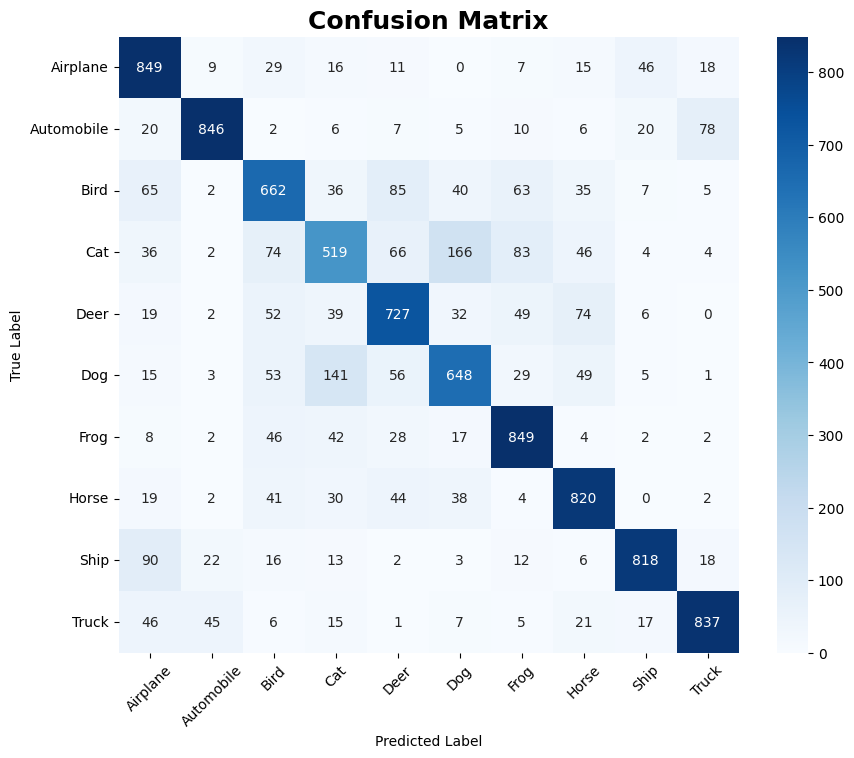

In [ ]:
# ==========================================================
# Confusion Matrix Heatmap
# ==========================================================

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "Confusion Matrix",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.xticks(rotation=45)

plt.yticks(rotation=0)

plt.show()

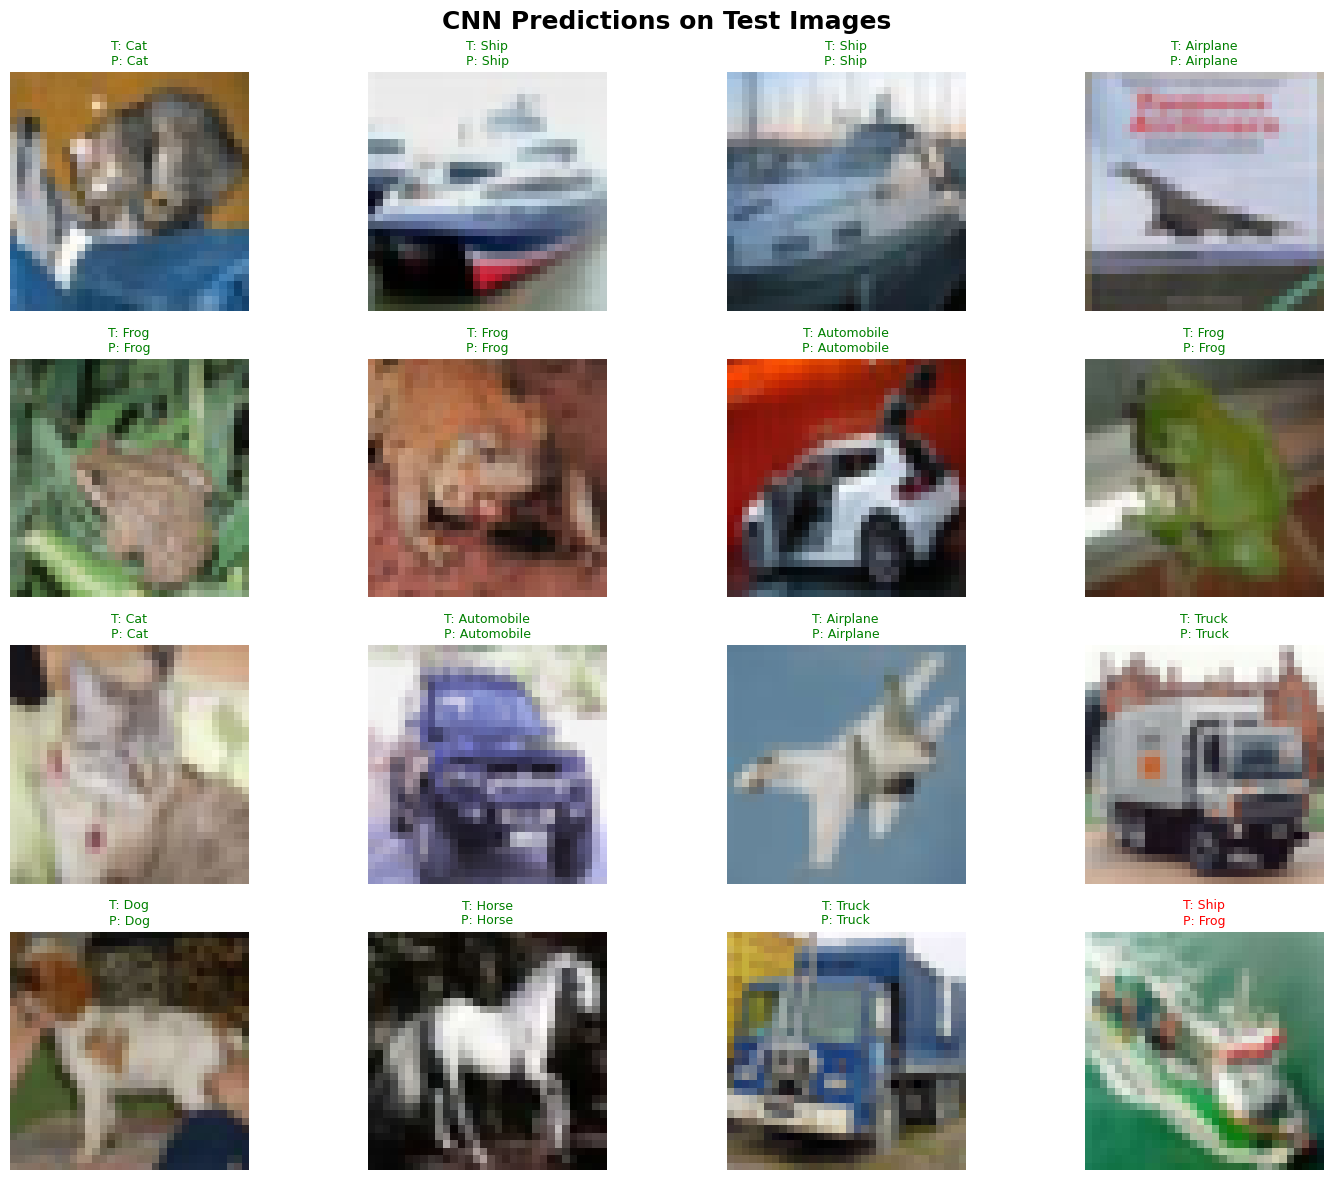

In [ ]:
# ==========================================================
# Display Sample Predictions
# ==========================================================

plt.figure(figsize=(15,12))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(X_test[i])

    true_label = class_names[y_true[i]]
    predicted_label = class_names[y_pred[i]]

    if true_label == predicted_label:
        color = "green"
    else:
        color = "red"

    plt.title(
        f"T: {true_label}\nP: {predicted_label}",
        fontsize=9,
        color=color
    )

    plt.axis("off")

plt.suptitle(
    "CNN Predictions on Test Images",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

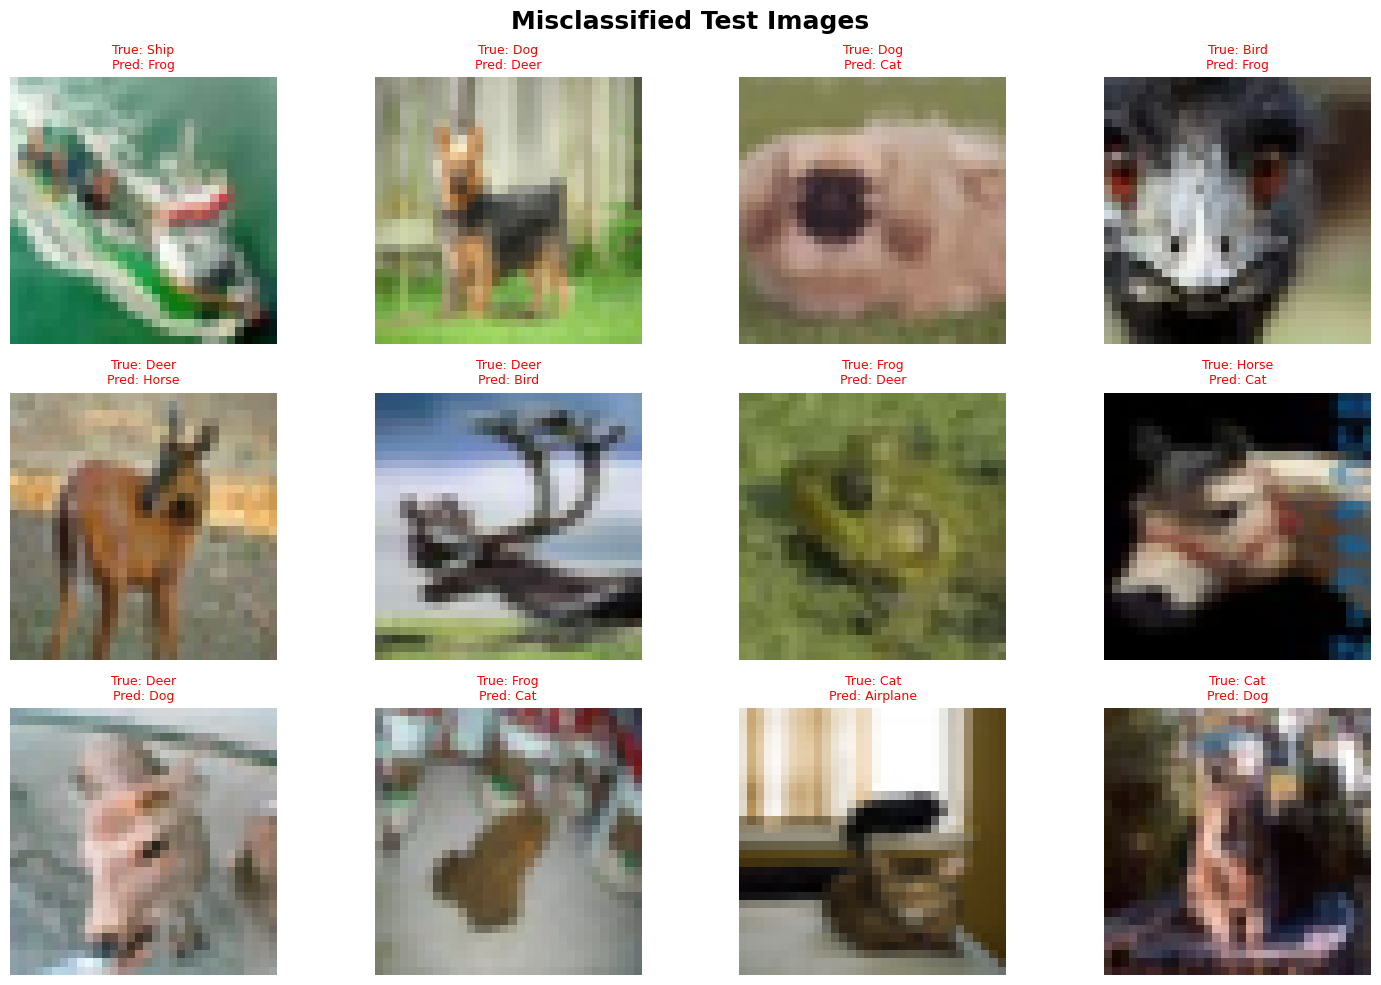

In [ ]:
# ==========================================================
# Display Misclassified Images
# ==========================================================

incorrect = np.where(y_true != y_pred)[0]

plt.figure(figsize=(15,10))

for i, idx in enumerate(incorrect[:12]):

    plt.subplot(3,4,i+1)

    plt.imshow(X_test[idx])

    plt.title(
        f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}",
        fontsize=9,
        color="red"
    )

    plt.axis("off")

plt.suptitle(
    "Misclassified Test Images",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [ ]:
# ==========================================================
# Display Convolution Layers
# ==========================================================

print("="*60)
print("Convolution Layers")
print("="*60)

for i, layer in enumerate(model.layers):

    if isinstance(layer, Conv2D):

        print(f"Layer {i} : {layer.name}")

Convolution Layers
Layer 0 : conv2d
Layer 3 : conv2d_1
Layer 6 : conv2d_2


In [ ]:
# ==========================================================
# Create Intermediate Model
# ==========================================================

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D

# Build the model if it hasn't been built yet
dummy_input = tf.random.normal((1, 32, 32, 3))
model(dummy_input)

# Collect outputs of all Conv2D layers
conv_layers = []

for layer in model.layers:
    if isinstance(layer, Conv2D):
        conv_layers.append(layer.output)

# Create feature extraction model
feature_model = Model(
    inputs=model.inputs,
    outputs=conv_layers
)

print("Feature Extraction Model Created Successfully")

Feature Extraction Model Created Successfully


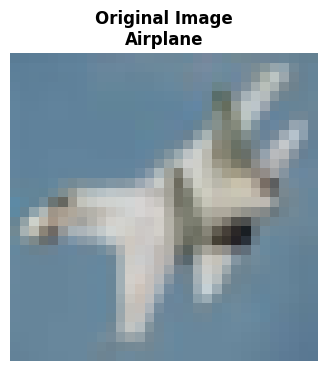

In [ ]:
# ==========================================================
# Select Image
# ==========================================================

image_index = 10

sample_image = X_test[image_index]

plt.figure(figsize=(4,4))

plt.imshow(sample_image)

plt.title(
    f"Original Image\n{class_names[y_true[image_index]]}",
    fontsize=12,
    fontweight="bold"
)

plt.axis("off")

plt.show()

In [ ]:
# ==========================================================
# Generate Feature Maps
# ==========================================================

sample = np.expand_dims(sample_image, axis=0)

feature_maps = feature_model.predict(sample)

print("Number of Convolution Layers :", len(feature_maps))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
Number of Convolution Layers : 3


In [ ]:
print("model exists:", "model" in globals())
print("feature_model exists:", "feature_model" in globals())
print("X_test exists:", "X_test" in globals())

model exists: True
feature_model exists: True
X_test exists: True


FEATURE MAP VISUALIZATION

Convolution Layer 1
Feature Map Shape : (1, 32, 32, 32)


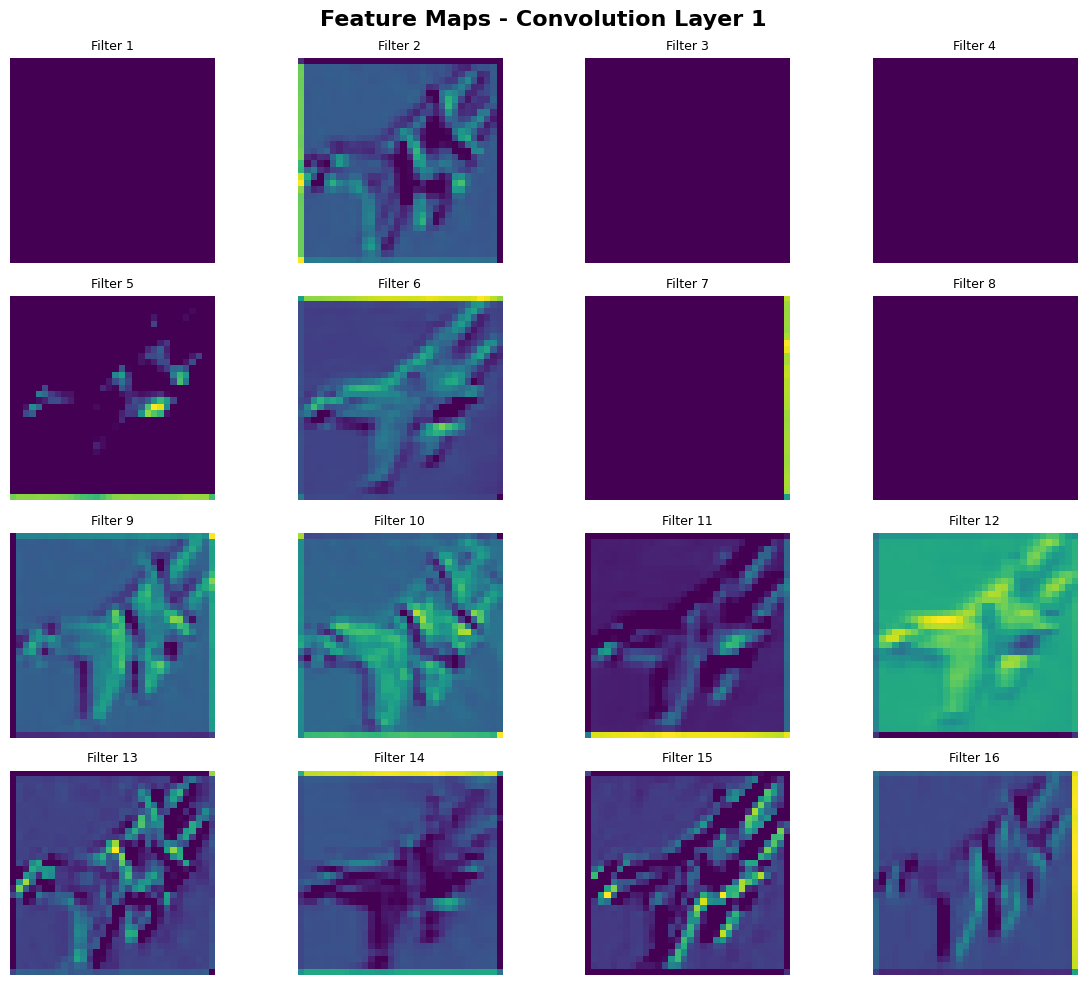


Convolution Layer 2
Feature Map Shape : (1, 16, 16, 64)


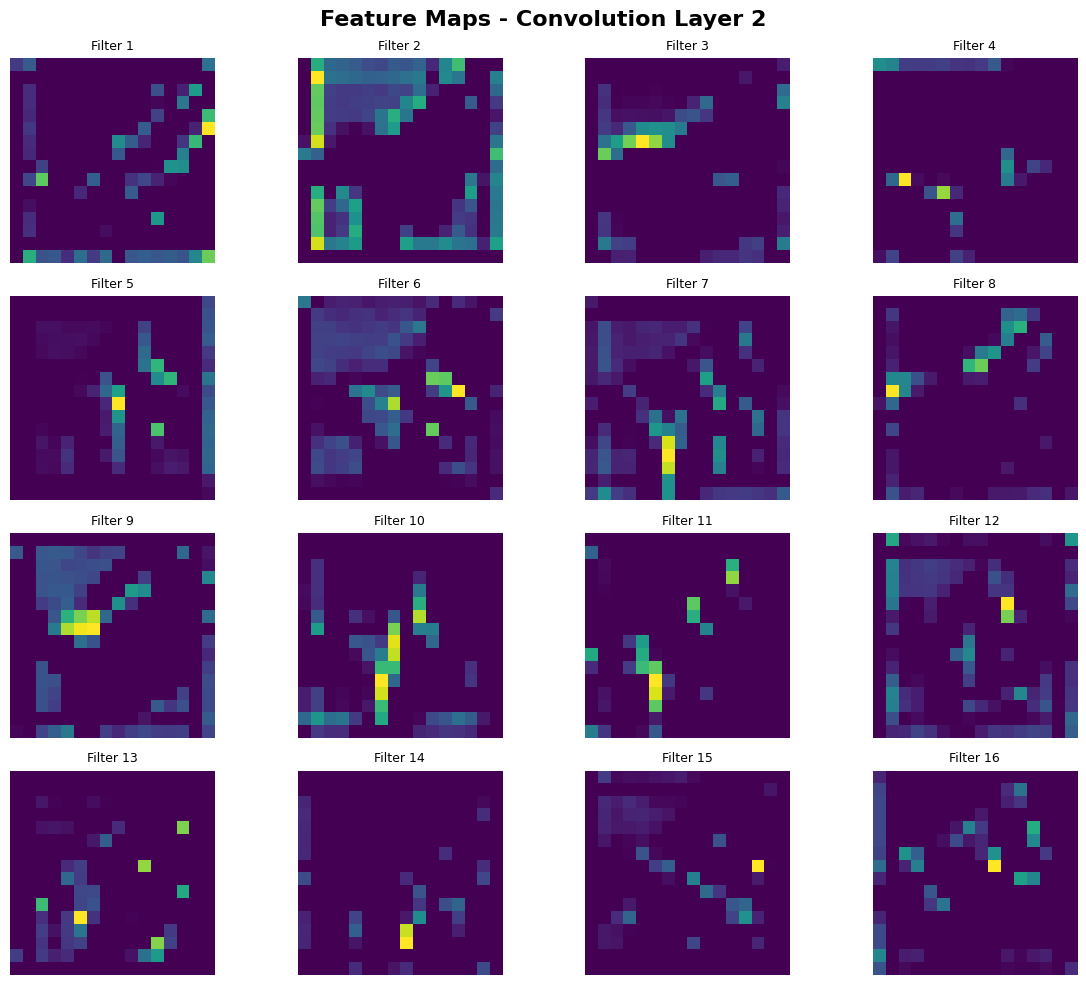


Convolution Layer 3
Feature Map Shape : (1, 8, 8, 128)


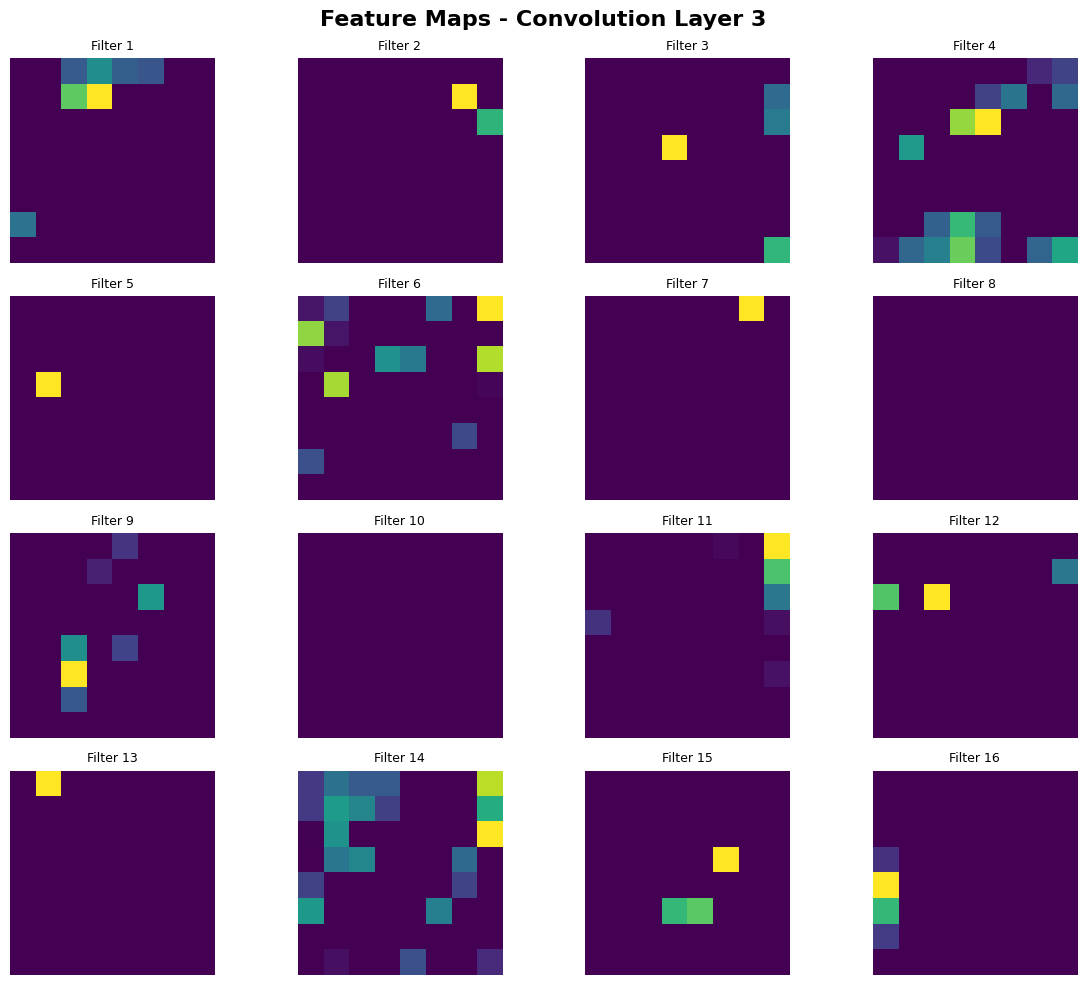

In [ ]:
# ==========================================================
# Visualize Feature Maps from Convolutional Layers
# ==========================================================

print("=" * 70)
print("FEATURE MAP VISUALIZATION")
print("=" * 70)

for layer_number, fmap in enumerate(feature_maps):

    print(f"\nConvolution Layer {layer_number + 1}")
    print(f"Feature Map Shape : {fmap.shape}")

    # Display maximum 16 feature maps
    num_filters = min(16, fmap.shape[-1])

    plt.figure(figsize=(12, 10))

    for i in range(num_filters):

        plt.subplot(4, 4, i + 1)

        plt.imshow(
            fmap[0, :, :, i],
            cmap="viridis"
        )

        plt.title(
            f"Filter {i + 1}",
            fontsize=9
        )

        plt.axis("off")

    plt.suptitle(
        f"Feature Maps - Convolution Layer {layer_number + 1}",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

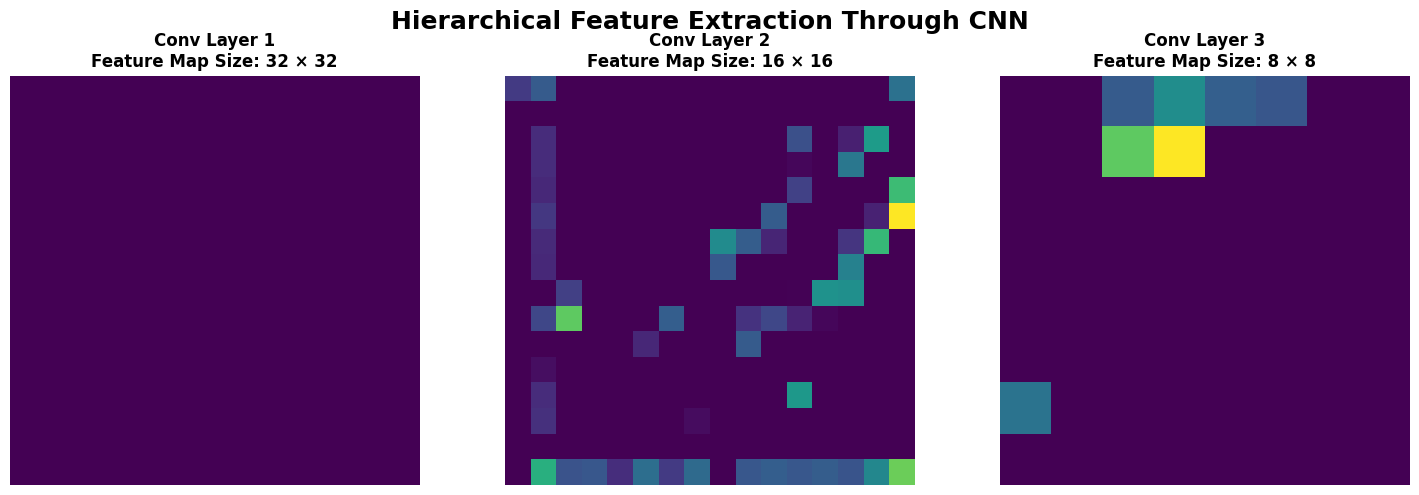

In [ ]:
# ==========================================================
# Hierarchical Feature Extraction Visualization
# ==========================================================

plt.figure(figsize=(15, 5))

for i, fmap in enumerate(feature_maps):

    plt.subplot(1, 3, i + 1)

    plt.imshow(
        fmap[0, :, :, 0],
        cmap="viridis"
    )

    plt.title(
        f"Conv Layer {i + 1}\n"
        f"Feature Map Size: "
        f"{fmap.shape[1]} × {fmap.shape[2]}",
        fontsize=12,
        fontweight="bold"
    )

    plt.axis("off")

plt.suptitle(
    "Hierarchical Feature Extraction Through CNN",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================================
# Convolutional Layer Parameter Analysis
# ==========================================================

print("=" * 70)
print("CONVOLUTIONAL LAYER PARAMETER ANALYSIS")
print("=" * 70)

conv_parameter_data = []

for layer in model.layers:

    if isinstance(layer, Conv2D):

        weights = layer.get_weights()

        kernel_weights = weights[0]
        bias_weights = weights[1]

        kernel_params = np.prod(kernel_weights.shape)
        bias_params = np.prod(bias_weights.shape)

        total_params = kernel_params + bias_params

        conv_parameter_data.append({
            "Layer": layer.name,
            "Filters": layer.filters,
            "Kernel Size": str(layer.kernel_size),
            "Input Channels": kernel_weights.shape[2],
            "Kernel Parameters": kernel_params,
            "Bias Parameters": bias_params,
            "Total Parameters": total_params
        })

conv_parameter_df = pd.DataFrame(conv_parameter_data)

display(conv_parameter_df)

CONVOLUTIONAL LAYER PARAMETER ANALYSIS


,Layer,Filters,Kernel Size,Input Channels,Kernel Parameters,Bias Parameters,Total Parameters
0,conv2d,32,"(3, 3)",3,864,32,896
1,conv2d_1,64,"(3, 3)",32,18432,64,18496
2,conv2d_2,128,"(3, 3)",64,73728,128,73856


In [ ]:
# ==========================================================
# Compare Max Pooling and Average Pooling
# ==========================================================

sample = X_test[10:11]

max_pool = MaxPooling2D(
    pool_size=(2, 2),
    strides=(2, 2)
)

avg_pool = AveragePooling2D(
    pool_size=(2, 2),
    strides=(2, 2)
)

max_output = max_pool(sample)
avg_output = avg_pool(sample)

print("=" * 70)
print("POOLING STRATEGY COMPARISON")
print("=" * 70)

print("Original Shape        :", sample.shape)
print("Max Pooling Shape     :", max_output.shape)
print("Average Pooling Shape :", avg_output.shape)

POOLING STRATEGY COMPARISON
Original Shape        : (1, 32, 32, 3)
Max Pooling Shape     : (1, 16, 16, 3)
Average Pooling Shape : (1, 16, 16, 3)


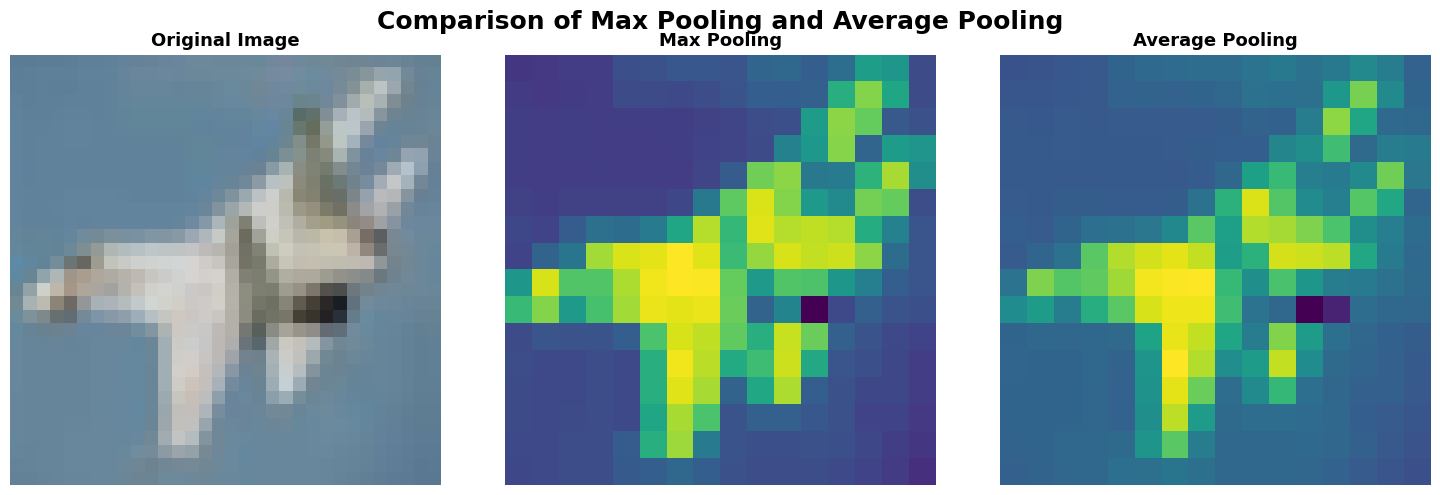

In [ ]:
# ==========================================================
# Visual Comparison of Pooling Strategies
# ==========================================================

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)

plt.imshow(sample[0])

plt.title(
    "Original Image",
    fontsize=13,
    fontweight="bold"
)

plt.axis("off")


plt.subplot(1, 3, 2)

plt.imshow(
    max_output[0, :, :, 0],
    cmap="viridis"
)

plt.title(
    "Max Pooling",
    fontsize=13,
    fontweight="bold"
)

plt.axis("off")


plt.subplot(1, 3, 3)

plt.imshow(
    avg_output[0, :, :, 0],
    cmap="viridis"
)

plt.title(
    "Average Pooling",
    fontsize=13,
    fontweight="bold"
)

plt.axis("off")


plt.suptitle(
    "Comparison of Max Pooling and Average Pooling",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================================
# Hyperparameter Analysis - Kernel, Stride and Padding
# ==========================================================

print("=" * 70)
print("KERNEL SIZE, STRIDE AND PADDING ANALYSIS")
print("=" * 70)

input_data = tf.random.normal((1, 32, 32, 3))

configs = [
    {
        "Kernel Size": (3, 3),
        "Stride": (1, 1),
        "Padding": "same"
    },
    {
        "Kernel Size": (3, 3),
        "Stride": (2, 2),
        "Padding": "same"
    },
    {
        "Kernel Size": (3, 3),
        "Stride": (1, 1),
        "Padding": "valid"
    },
    {
        "Kernel Size": (5, 5),
        "Stride": (1, 1),
        "Padding": "same"
    }
]

hyperparameter_results = []

for config in configs:

    layer = Conv2D(
        filters=32,
        kernel_size=config["Kernel Size"],
        strides=config["Stride"],
        padding=config["Padding"]
    )

    output = layer(input_data)

    hyperparameter_results.append({
        "Kernel Size": str(config["Kernel Size"]),
        "Stride": str(config["Stride"]),
        "Padding": config["Padding"],
        "Output Shape": str(tuple(output.shape)),
        "Parameters": layer.count_params()
    })

hyperparameter_df = pd.DataFrame(hyperparameter_results)

display(hyperparameter_df)

KERNEL SIZE, STRIDE AND PADDING ANALYSIS


,Kernel Size,Stride,Padding,Output Shape,Parameters
0,"(3, 3)","(1, 1)",same,"(1, 32, 32, 32)",896
1,"(3, 3)","(2, 2)",same,"(1, 16, 16, 32)",896
2,"(3, 3)","(1, 1)",valid,"(1, 30, 30, 32)",896
3,"(5, 5)","(1, 1)",same,"(1, 32, 32, 32)",2432


In [ ]:
# ==========================================================
# Prepare Small Dataset for Hyperparameter Experiments
# ==========================================================

X_hp_train = X_train[:10000]
y_hp_train = y_train_encoded[:10000]

X_hp_val = X_train[10000:12000]
y_hp_val = y_train_encoded[10000:12000]

print("=" * 70)
print("HYPERPARAMETER EXPERIMENT DATA")
print("=" * 70)

print("Training Samples  :", len(X_hp_train))
print("Validation Samples:", len(X_hp_val))

HYPERPARAMETER EXPERIMENT DATA
Training Samples  : 10000
Validation Samples: 2000


In [ ]:
# ==========================================================
# Lightweight CNN for Hyperparameter Experiments
# ==========================================================

def build_hp_model(
    filters=(32, 64),
    kernel_size=(3, 3),
    optimizer="adam"
):

    hp_model = Sequential([

        Conv2D(
            filters=filters[0],
            kernel_size=kernel_size,
            activation="relu",
            padding="same",
            input_shape=(32, 32, 3)
        ),

        MaxPooling2D((2, 2)),

        Conv2D(
            filters=filters[1],
            kernel_size=kernel_size,
            activation="relu",
            padding="same"
        ),

        MaxPooling2D((2, 2)),

        Flatten(),

        Dense(128, activation="relu"),

        Dropout(0.5),

        Dense(10, activation="softmax")
    ])

    hp_model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return hp_model

In [ ]:
# ==========================================================
# Kernel Size Performance Comparison
# ==========================================================

kernel_results = []

for kernel in [(3, 3), (5, 5)]:

    print("=" * 70)
    print(f"Training Kernel Size: {kernel}")
    print("=" * 70)

    hp_model = build_hp_model(
        filters=(32, 64),
        kernel_size=kernel,
        optimizer="adam"
    )

    hp_history = hp_model.fit(
        X_hp_train,
        y_hp_train,
        validation_data=(X_hp_val, y_hp_val),
        epochs=3,
        batch_size=64,
        verbose=1
    )

    test_loss, test_accuracy = hp_model.evaluate(
        X_test[:2000],
        y_test_encoded[:2000],
        verbose=0
    )

    kernel_results.append({
        "Kernel Size": str(kernel),
        "Test Accuracy": test_accuracy,
        "Parameters": hp_model.count_params()
    })

kernel_df = pd.DataFrame(kernel_results)

print("\nKernel Size Comparison:")
display(kernel_df)

Training Kernel Size: (3, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 119ms/step - accuracy: 0.2744 - loss: 1.9623 - val_accuracy: 0.4055 - val_loss: 1.6895
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 111ms/step - accuracy: 0.3943 - loss: 1.6659 - val_accuracy: 0.4510 - val_loss: 1.5031
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 112ms/step - accuracy: 0.4465 - loss: 1.5171 - val_accuracy: 0.4905 - val_loss: 1.4097
Training Kernel Size: (5, 5)
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 39s 236ms/step - accuracy: 0.2592 - loss: 1.9995 - val_accuracy: 0.4055 - val_loss: 1.7323
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 228ms/step - accuracy: 0.3622 - loss: 1.7185 - val_accuracy: 0.4545 - val_loss: 1.5309
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 39s 246ms/step - accuracy: 0.4189 - loss: 1.5872 - val_accuracy: 0.4790 - val_loss: 1.4898

Kernel Size Comparison:


,Kernel Size,Test Accuracy,Parameters
0,"(3, 3)",0.5010,545098
1,"(5, 5)",0.4765,579402


In [ ]:
# ==========================================================
# Number of Filters Performance Comparison
# ==========================================================

filter_results = []

filter_configs = [
    (16, 32),
    (32, 64)
]

for filters in filter_configs:

    print("=" * 70)
    print(f"Filter Configuration: {filters}")
    print("=" * 70)

    hp_model = build_hp_model(
        filters=filters,
        kernel_size=(3, 3),
        optimizer="adam"
    )

    hp_history = hp_model.fit(
        X_hp_train,
        y_hp_train,
        validation_data=(X_hp_val, y_hp_val),
        epochs=3,
        batch_size=64,
        verbose=1
    )

    test_loss, test_accuracy = hp_model.evaluate(
        X_test[:2000],
        y_test_encoded[:2000],
        verbose=0
    )

    filter_results.append({
        "Filters": str(filters),
        "Test Accuracy": test_accuracy,
        "Parameters": hp_model.count_params()
    })

filter_df = pd.DataFrame(filter_results)

print("\nFilter Comparison:")
display(filter_df)

Filter Configuration: (16, 32)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 83ms/step - accuracy: 0.2330 - loss: 2.0440 - val_accuracy: 0.3435 - val_loss: 1.7914
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - accuracy: 0.3399 - loss: 1.7854 - val_accuracy: 0.4315 - val_loss: 1.6513
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 59ms/step - accuracy: 0.3909 - loss: 1.6572 - val_accuracy: 0.4580 - val_loss: 1.5180
Filter Configuration: (32, 64)
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 118ms/step - accuracy: 0.2486 - loss: 2.0322 - val_accuracy: 0.3800 - val_loss: 1.7311
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 112ms/step - accuracy: 0.3842 - loss: 1.6825 - val_accuracy: 0.4700 - val_loss: 1.4994
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 122ms/step - accuracy: 0.4438 - loss: 1.5267 - val_accuracy: 0.4970 - val_loss: 1.4050

Filter Comparison:


,Filters,Test Accuracy,Parameters
0,"(16, 32)",0.464,268650
1,"(32, 64)",0.513,545098


In [ ]:
# ==========================================================
# Optimizer Performance Comparison
# ==========================================================

optimizer_results = []

optimizer_configs = {
    "Adam": tf.keras.optimizers.Adam(),
    "SGD": tf.keras.optimizers.SGD(learning_rate=0.01)
}

for optimizer_name, optimizer in optimizer_configs.items():

    print("=" * 70)
    print(f"Optimizer: {optimizer_name}")
    print("=" * 70)

    hp_model = build_hp_model(
        filters=(32, 64),
        kernel_size=(3, 3),
        optimizer=optimizer
    )

    hp_history = hp_model.fit(
        X_hp_train,
        y_hp_train,
        validation_data=(X_hp_val, y_hp_val),
        epochs=3,
        batch_size=64,
        verbose=1
    )

    test_loss, test_accuracy = hp_model.evaluate(
        X_test[:2000],
        y_test_encoded[:2000],
        verbose=0
    )

    optimizer_results.append({
        "Optimizer": optimizer_name,
        "Test Accuracy": test_accuracy
    })

optimizer_df = pd.DataFrame(optimizer_results)

print("\nOptimizer Comparison:")
display(optimizer_df)

Optimizer: Adam
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 120ms/step - accuracy: 0.2630 - loss: 1.9934 - val_accuracy: 0.3855 - val_loss: 1.7155
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 119ms/step - accuracy: 0.3810 - loss: 1.6853 - val_accuracy: 0.4695 - val_loss: 1.5000
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 117ms/step - accuracy: 0.4261 - loss: 1.5501 - val_accuracy: 0.5005 - val_loss: 1.4197
Optimizer: SGD
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 124ms/step - accuracy: 0.1438 - loss: 2.2790 - val_accuracy: 0.1885 - val_loss: 2.2474
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step - accuracy: 0.1869 - loss: 2.2122 - val_accuracy: 0.2115 - val_loss: 2.1475
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 108ms/step - accuracy: 0.2234 - loss: 2.1240 - val_accuracy: 0.2780 - val_loss: 2.0481

Optimizer Comparison:


,Optimizer,Test Accuracy
0,Adam,0.516
1,SGD,0.288


In [ ]:
# ==========================================================
# Batch Size Performance Comparison
# ==========================================================

batch_results = []

for batch_size in [32, 64]:

    print("=" * 70)
    print(f"Batch Size: {batch_size}")
    print("=" * 70)

    hp_model = build_hp_model(
        filters=(32, 64),
        kernel_size=(3, 3),
        optimizer="adam"
    )

    hp_history = hp_model.fit(
        X_hp_train,
        y_hp_train,
        validation_data=(X_hp_val, y_hp_val),
        epochs=3,
        batch_size=batch_size,
        verbose=1
    )

    test_loss, test_accuracy = hp_model.evaluate(
        X_test[:2000],
        y_test_encoded[:2000],
        verbose=0
    )

    batch_results.append({
        "Batch Size": batch_size,
        "Test Accuracy": test_accuracy
    })

batch_df = pd.DataFrame(batch_results)

print("\nBatch Size Comparison:")
display(batch_df)

Batch Size: 32


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 79ms/step - accuracy: 0.2725 - loss: 1.9612 - val_accuracy: 0.4230 - val_loss: 1.6566
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 62ms/step - accuracy: 0.3970 - loss: 1.6506 - val_accuracy: 0.4875 - val_loss: 1.4692
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 67ms/step - accuracy: 0.4542 - loss: 1.4962 - val_accuracy: 0.5060 - val_loss: 1.3502
Batch Size: 64
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 116ms/step - accuracy: 0.2640 - loss: 2.0164 - val_accuracy: 0.3860 - val_loss: 1.7890
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 119ms/step - accuracy: 0.3903 - loss: 1.6689 - val_accuracy: 0.4535 - val_loss: 1.5359
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step - accuracy: 0.4473 - loss: 1.5341 - val_accuracy: 0.4815 - val_loss: 1.4653

Batch Size Comparison:


,Batch Size,Test Accuracy
0,32,0.5260
1,64,0.4905


In [ ]:
# ==========================================================
# Hyperparameter Experiment Summary
# ==========================================================

print("=" * 70)
print("HYPERPARAMETER EXPERIMENT SUMMARY")
print("=" * 70)

print("\n1. Kernel Size:")
display(kernel_df)

print("\n2. Number of Filters:")
display(filter_df)

print("\n3. Optimizer:")
display(optimizer_df)

print("\n4. Batch Size:")
display(batch_df)

HYPERPARAMETER EXPERIMENT SUMMARY

1. Kernel Size:


,Kernel Size,Test Accuracy,Parameters
0,"(3, 3)",0.5010,545098
1,"(5, 5)",0.4765,579402



2. Number of Filters:


,Filters,Test Accuracy,Parameters
0,"(16, 32)",0.464,268650
1,"(32, 64)",0.513,545098



3. Optimizer:


,Optimizer,Test Accuracy
0,Adam,0.516
1,SGD,0.288



4. Batch Size:


,Batch Size,Test Accuracy
0,32,0.5260
1,64,0.4905


In [ ]:
# ==========================================================
# FINAL CNN RESULTS SUMMARY
# ==========================================================

print("=" * 70)
print("FINAL CNN EXPERIMENT RESULTS")
print("=" * 70)

# Calculate final test predictions if required
y_test_pred_prob = model.predict(X_test, verbose=0)

y_test_pred = np.argmax(
    y_test_pred_prob,
    axis=1
)

y_test_actual = y_test.flatten()

# Calculate metrics
final_accuracy = accuracy_score(
    y_test_actual,
    y_test_pred
)

final_precision = precision_score(
    y_test_actual,
    y_test_pred,
    average="weighted"
)

final_recall = recall_score(
    y_test_actual,
    y_test_pred,
    average="weighted"
)

final_f1 = f1_score(
    y_test_actual,
    y_test_pred,
    average="weighted"
)

# Training history
best_train_accuracy = max(history.history["accuracy"])
best_val_accuracy = max(history.history["val_accuracy"])

# Create final table
final_results = pd.DataFrame({

    "Parameter": [

        "Dataset",
        "Training Images",
        "Testing Images",
        "Image Size",
        "Number of Classes",

        "Convolutional Layers",
        "Filters",
        "Kernel Size",
        "Padding",
        "Pooling",

        "Optimizer",
        "Loss Function",
        "Batch Size",
        "Epochs",

        "Total Parameters",

        "Best Training Accuracy",
        "Best Validation Accuracy",

        "Test Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],

    "Value": [

        "CIFAR-10",
        len(X_train),
        len(X_test),
        "32 × 32 × 3",
        10,

        3,
        "32 → 64 → 128",
        "3 × 3",
        "Same",
        "Max Pooling",

        "Adam",
        "Categorical Crossentropy",
        64,
        20,

        model.count_params(),

        f"{best_train_accuracy:.4f}",
        f"{best_val_accuracy:.4f}",

        f"{final_accuracy:.4f}",
        f"{final_precision:.4f}",
        f"{final_recall:.4f}",
        f"{final_f1:.4f}"
    ]
})

display(final_results)

FINAL CNN EXPERIMENT RESULTS


,Parameter,Value
0,Dataset,CIFAR-10
1,Training Images,50000
2,Testing Images,10000
3,Image Size,32 × 32 × 3
4,Number of Classes,10
5,Convolutional Layers,3
6,Filters,32 → 64 → 128
7,Kernel Size,3 × 3
8,Padding,Same
9,Pooling,Max Pooling


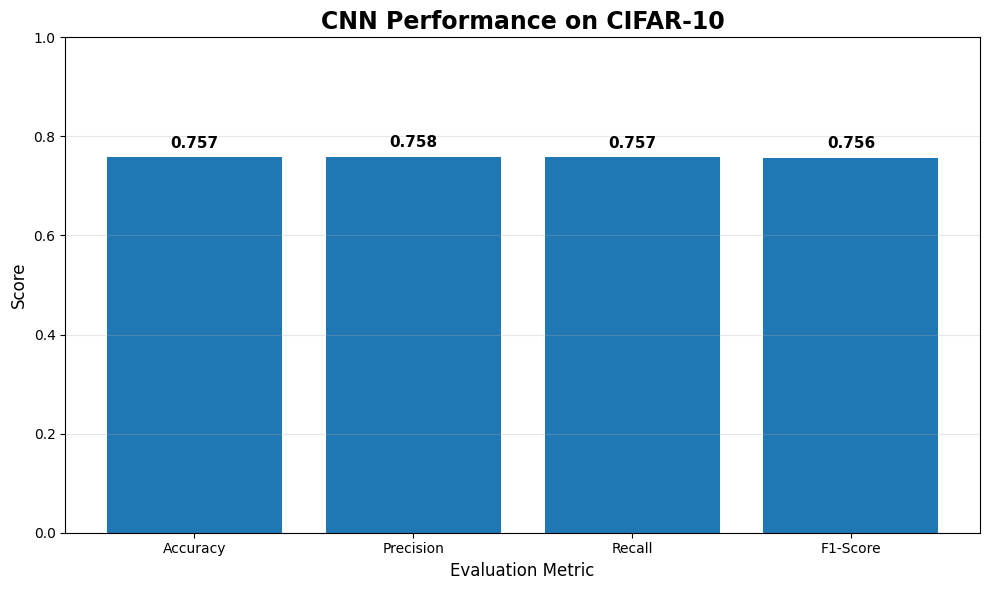

In [ ]:
# ==========================================================
# FINAL PERFORMANCE METRICS
# ==========================================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

scores = [
    final_accuracy,
    final_precision,
    final_recall,
    final_f1
]

plt.figure(figsize=(10, 6))

bars = plt.bar(
    metrics,
    scores
)

plt.ylim(0, 1)

plt.xlabel(
    "Evaluation Metric",
    fontsize=12
)

plt.ylabel(
    "Score",
    fontsize=12
)

plt.title(
    "CNN Performance on CIFAR-10",
    fontsize=17,
    fontweight="bold"
)

for bar, score in zip(bars, scores):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.02,
        f"{score:.3f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

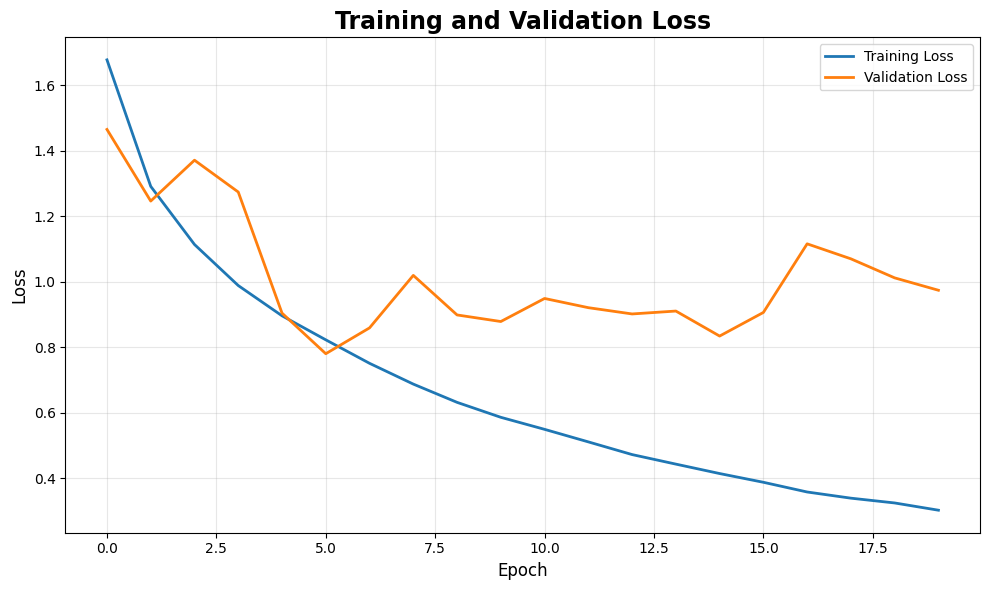

In [ ]:
# ==========================================================
# FINAL TRAINING AND VALIDATION LOSS
# ==========================================================

plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.xlabel(
    "Epoch",
    fontsize=12
)

plt.ylabel(
    "Loss",
    fontsize=12
)

plt.title(
    "Training and Validation Loss",
    fontsize=17,
    fontweight="bold"
)

plt.legend()

plt.grid(

    alpha=0.3
)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================================
# CREATE FIGURES FOLDER
# ==========================================================

import os

os.makedirs("figures", exist_ok=True)

print("Figures folder is ready.")

Figures folder is ready.


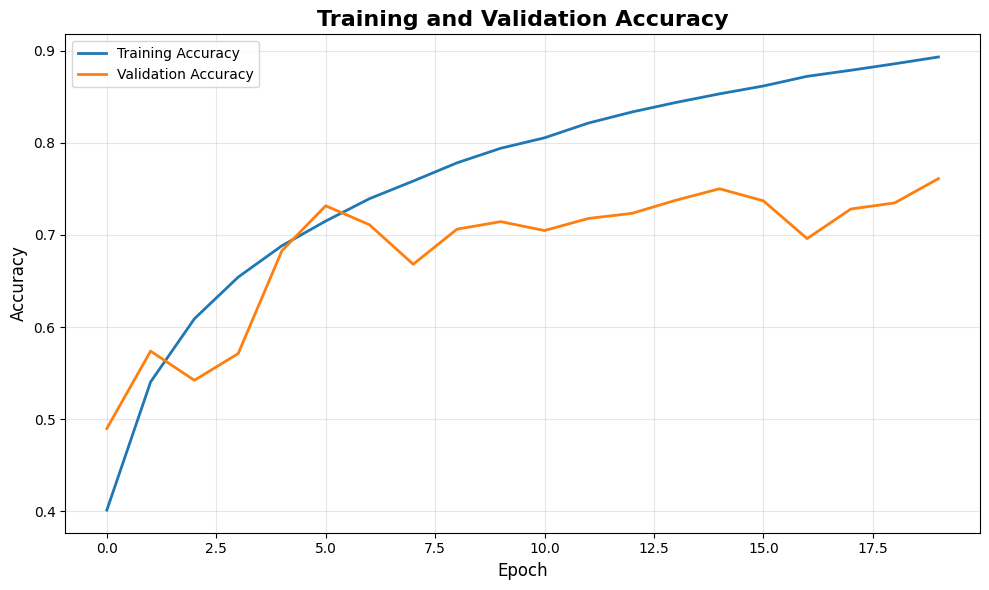

Saved: figures/01_training_validation_accuracy.png


In [ ]:
# ==========================================================
# FIGURE 1: TRAINING VS VALIDATION ACCURACY
# ==========================================================

plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy",
    linewidth=2
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy",
    linewidth=2
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)

plt.title(
    "Training and Validation Accuracy",
    fontsize=16,
    fontweight="bold"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "figures/01_training_validation_accuracy.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("Saved: figures/01_training_validation_accuracy.png")

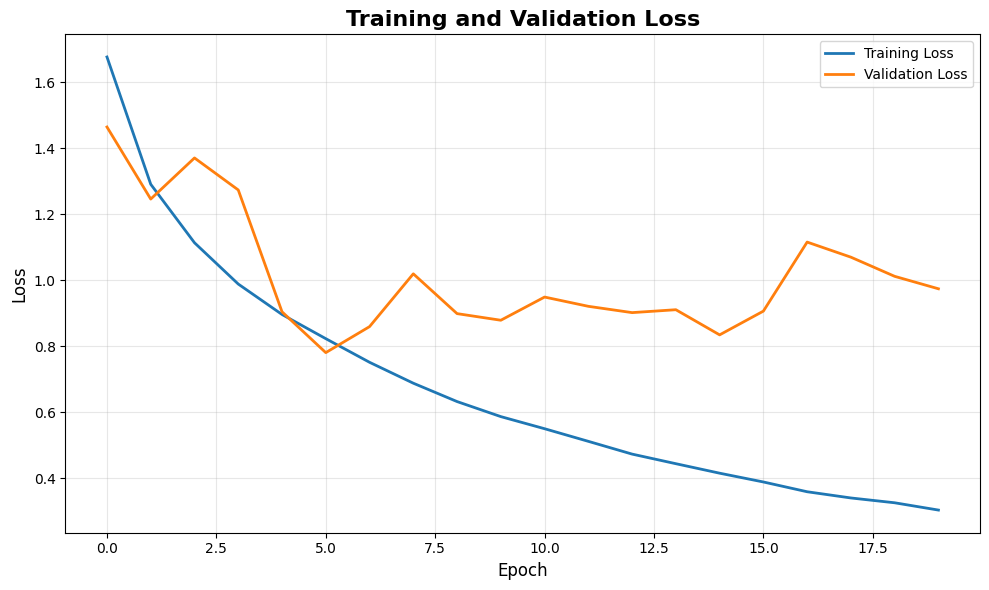

Saved: figures/02_training_validation_loss.png


In [ ]:
# ==========================================================
# FIGURE 2: TRAINING VS VALIDATION LOSS
# ==========================================================

plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)

plt.title(
    "Training and Validation Loss",
    fontsize=16,
    fontweight="bold"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "figures/02_training_validation_loss.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("Saved: figures/02_training_validation_loss.png")

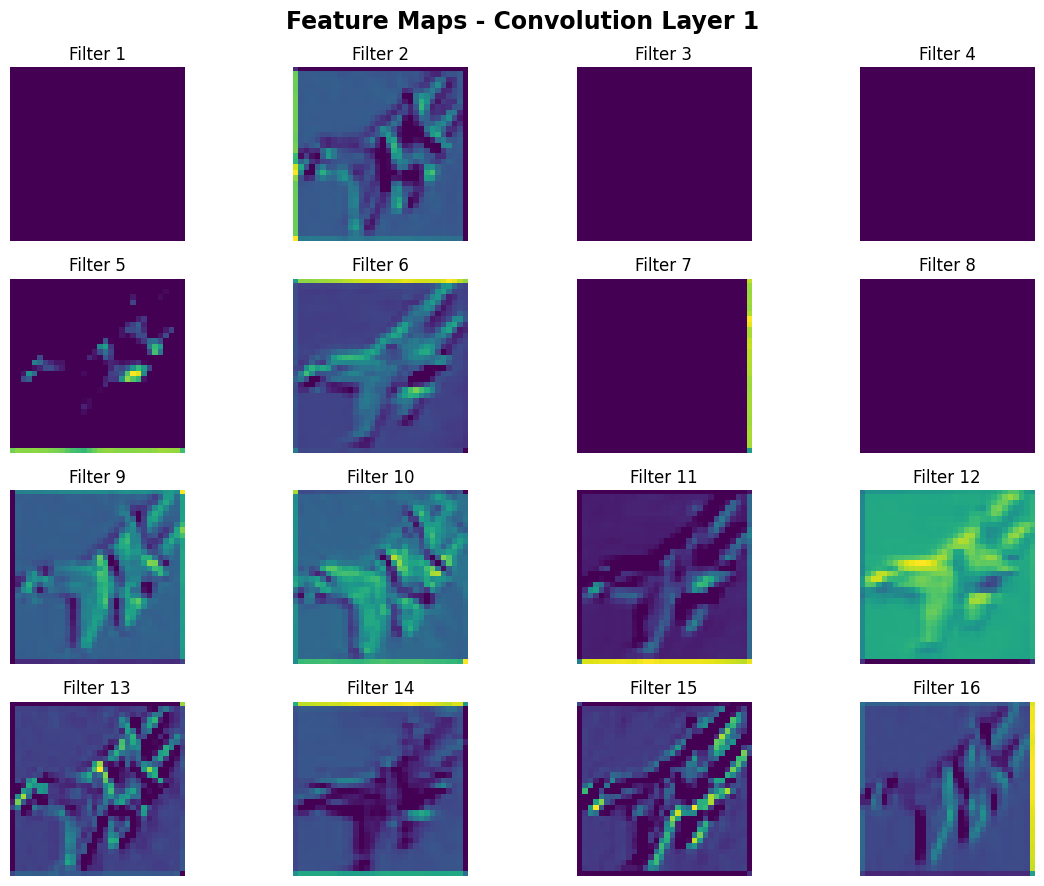

Saved: figures/03_feature_maps_layer1.png


In [ ]:
# ==========================================================
# FIGURE 3: FEATURE MAPS - CONVOLUTION LAYER 1
# ==========================================================

fmap = feature_maps[0]

num_filters = min(16, fmap.shape[-1])

plt.figure(figsize=(12, 9))

for i in range(num_filters):

    plt.subplot(4, 4, i + 1)

    plt.imshow(
        fmap[0, :, :, i],
        cmap="viridis"
    )

    plt.title(f"Filter {i + 1}")
    plt.axis("off")

plt.suptitle(
    "Feature Maps - Convolution Layer 1",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "figures/03_feature_maps_layer1.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("Saved: figures/03_feature_maps_layer1.png")

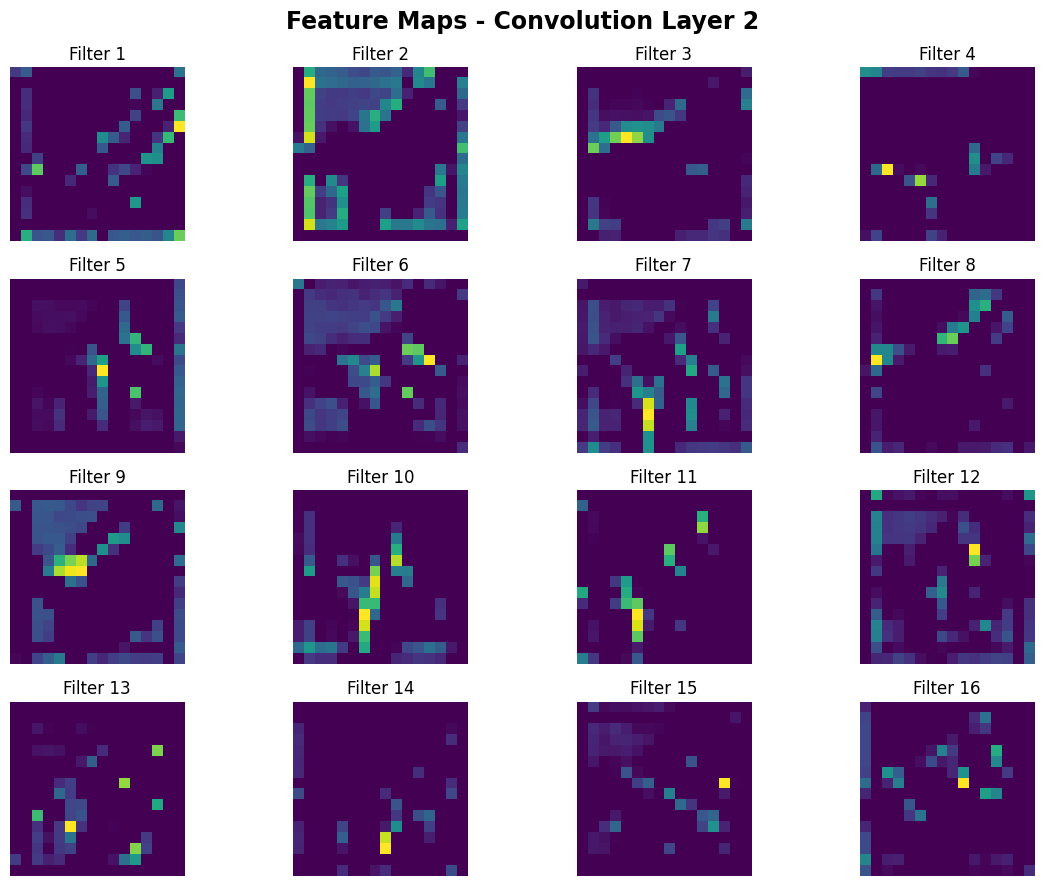

Saved: figures/04_feature_maps_layer2.png


In [ ]:
# ==========================================================
# FIGURE 4: FEATURE MAPS - CONVOLUTION LAYER 2
# ==========================================================

fmap = feature_maps[1]

num_filters = min(16, fmap.shape[-1])

plt.figure(figsize=(12, 9))

for i in range(num_filters):

    plt.subplot(4, 4, i + 1)

    plt.imshow(
        fmap[0, :, :, i],
        cmap="viridis"
    )

    plt.title(f"Filter {i + 1}")
    plt.axis("off")

plt.suptitle(
    "Feature Maps - Convolution Layer 2",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "figures/04_feature_maps_layer2.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("Saved: figures/04_feature_maps_layer2.png")

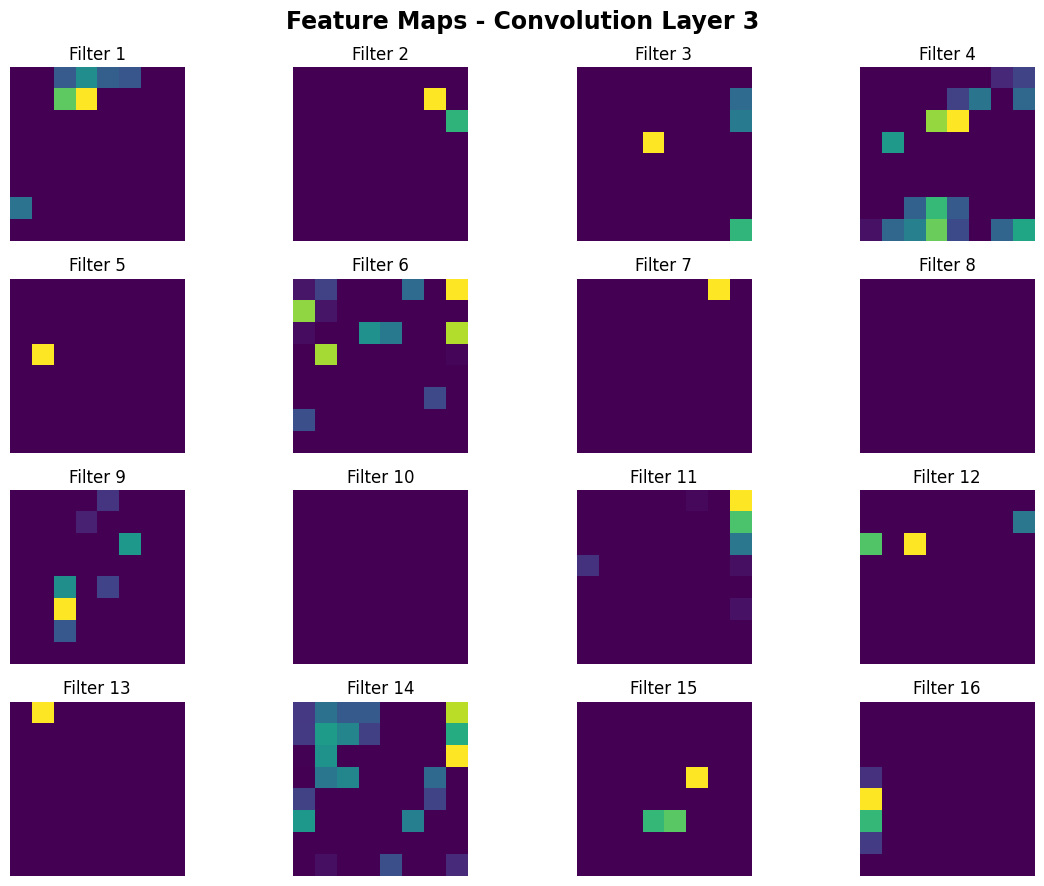

Saved: figures/05_feature_maps_layer3.png


In [ ]:
# ==========================================================
# FIGURE 5: FEATURE MAPS - CONVOLUTION LAYER 3
# ==========================================================

fmap = feature_maps[2]

num_filters = min(16, fmap.shape[-1])

plt.figure(figsize=(12, 9))

for i in range(num_filters):

    plt.subplot(4, 4, i + 1)

    plt.imshow(
        fmap[0, :, :, i],
        cmap="viridis"
    )

    plt.title(f"Filter {i + 1}")
    plt.axis("off")

plt.suptitle(
    "Feature Maps - Convolution Layer 3",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "figures/05_feature_maps_layer3.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("Saved: figures/05_feature_maps_layer3.png")

In [ ]:
# ==========================================================
# FIGURE 6: MAX POOLING VS AVERAGE POOLING
# ==========================================================

sample = X_test[10:11]

max_pool = MaxPooling2D(
    pool_size=(2, 2),
    strides=(2, 2)
)

avg_pool = AveragePooling2D(
    pool_size=(2, 2),
    strides=(2, 2)
)

max_output = max_pool(sample)
avg_output = avg_pool(sample)

plt.figure(figsize=(15, 5))

# Original
plt.subplot(1, 3, 1)

plt.imshow(sample[0])

plt.title(
    "Original Image",
    fontsize=13,
    fontweight="bold"
)

plt.axis("off")

# Max Pooling
plt.subplot(1, 3, 2)

plt.imshow(
    max_output[0, :, :, 0],
    cmap="viridis"
)

plt.title(
    "Max Pooling",
    fontsize=13,
    fontweight="bold"
)

plt.axis("off")

# Average Pooling
plt.subplot(1, 3, 3)

plt.imshow(
    avg_output[0, :, :, 0],
    cmap="viridis"
)

plt.title(
    "Average Pooling",
    fontsize=13,
    fontweight="bold"
)

plt.axis("off")

plt.suptitle(
    "Comparison of Pooling Strategies",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "figures/06_pooling_comparison.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("Saved: figures/06_pooling_comparison.png")

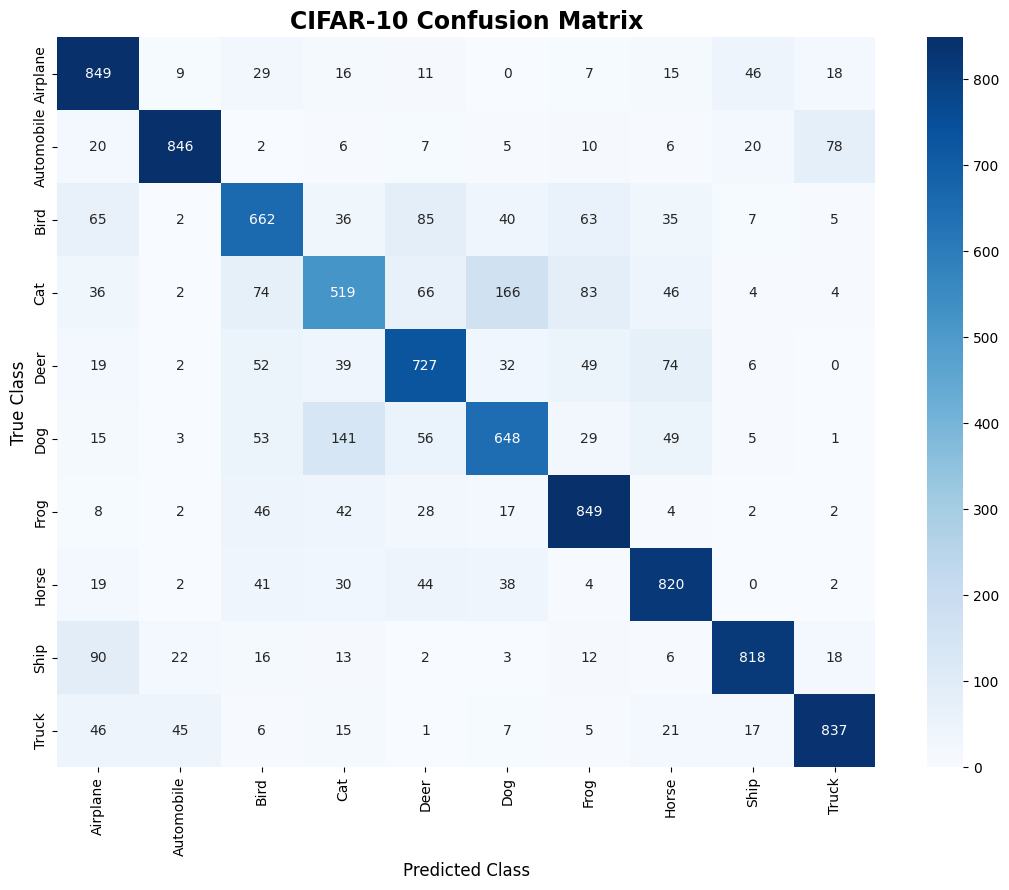

Saved: figures/07_confusion_matrix.png


In [ ]:
# ==========================================================
# FIGURE 7: CONFUSION MATRIX
# ==========================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate predictions
y_pred_prob = model.predict(
    X_test,
    verbose=0
)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

y_true = y_test.flatten()

# CIFAR-10 class names
class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

# Confusion matrix
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(11, 9))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel(
    "Predicted Class",
    fontsize=12
)

plt.ylabel(
    "True Class",
    fontsize=12
)

plt.title(
    "CIFAR-10 Confusion Matrix",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "figures/07_confusion_matrix.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("Saved: figures/07_confusion_matrix.png")

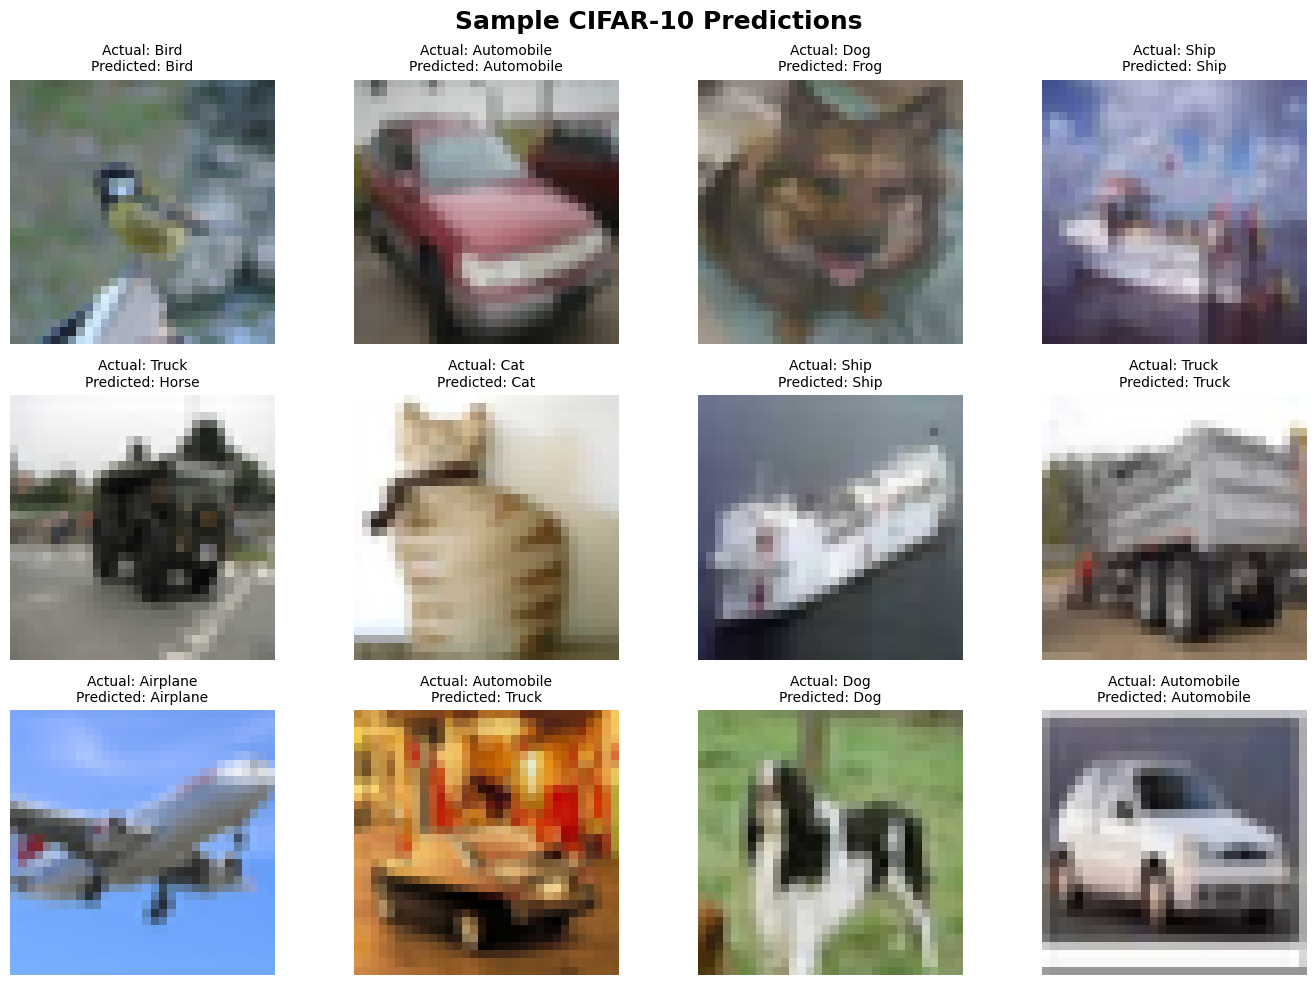

Saved: figures/08_sample_predictions.png


In [ ]:
# ==========================================================
# FIGURE 8: SAMPLE PREDICTIONS
# ==========================================================

import random

# Select 12 random test images
np.random.seed(42)

sample_indices = np.random.choice(
    len(X_test),
    12,
    replace=False
)

plt.figure(figsize=(14, 10))

for plot_number, index in enumerate(sample_indices):

    plt.subplot(3, 4, plot_number + 1)

    plt.imshow(X_test[index])

    actual_label = class_names[y_true[index]]
    predicted_label = class_names[y_pred[index]]

    plt.title(
        f"Actual: {actual_label}\n"
        f"Predicted: {predicted_label}",
        fontsize=10
    )

    plt.axis("off")

plt.suptitle(
    "Sample CIFAR-10 Predictions",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "figures/08_sample_predictions.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("Saved: figures/08_sample_predictions.png")

In [ ]:
# ==========================================================
# CHECK ALL REPORT FIGURES
# ==========================================================

import os

figure_files = [
    "01_training_validation_accuracy.png",
    "02_training_validation_loss.png",
    "03_feature_maps_layer1.png",
    "04_feature_maps_layer2.png",
    "05_feature_maps_layer3.png",
    "06_pooling_comparison.png",
    "07_confusion_matrix.png",
    "08_sample_predictions.png"
]

print("=" * 70)
print("REPORT FIGURE CHECK")
print("=" * 70)

for filename in figure_files:

    path = os.path.join(
        "figures",
        filename
    )

    if os.path.exists(path):

        size_kb = os.path.getsize(path) / 1024

        print(
            f"✓ {filename:<45} "
            f"{size_kb:.1f} KB"
        )

    else:

        print(
            f"✗ {filename:<45} NOT FOUND"
        )

print("=" * 70)

REPORT FIGURE CHECK
✓ 01_training_validation_accuracy.png           396.8 KB
✓ 02_training_validation_loss.png               402.6 KB
✓ 03_feature_maps_layer1.png                    271.4 KB
✓ 04_feature_maps_layer2.png                    242.9 KB
✓ 05_feature_maps_layer3.png                    234.2 KB
✓ 06_pooling_comparison.png                     201.2 KB
✓ 07_confusion_matrix.png                       643.3 KB
✓ 08_sample_predictions.png                     481.2 KB
